# 02 Feature Extraction
**ADHD EEG Classification Project**

**Goal:** Transform raw EEG signals into a model-ready feature matrix one row per subject.

**Features extracted per subject:**
- Absolute band power (Delta, Theta, Alpha, Beta) × 19 channels = **76 features**
- Theta/Beta ratio × 19 channels = **19 features**
- Statistical features (mean, variance, skewness, kurtosis) × 19 channels = **76 features**

**Total: 171 features per subject → feature matrix shape: (121, 171)**

## 0. Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
os.makedirs('plots', exist_ok=True)

SAMPLING_RATE = 128
BANDS = {
    'Delta': (1,  4),
    'Theta': (4,  8),
    'Alpha': (8,  12),
    'Beta':  (12, 30)
}
CHANNELS = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
            'F7','F8','T7','T8','P7','P8','Fz','Cz','Pz']

FILE_PATH = r'C:\Users\albader\OneDrive\Desktop\Data Science and Analytics\Projects\adhd-eeg-classification\data\adhdata.csv'
df_raw = pd.read_csv(FILE_PATH)

def get_subject(subject_id):
    rows = df_raw[df_raw['ID'] == subject_id]
    return rows[CHANNELS].values.astype(float), rows['Class'].iloc[0]

all_ids = df_raw['ID'].unique()
print(f'Loaded {len(df_raw):,} rows | {len(all_ids)} subjects')

Loaded 2,166,383 rows | 121 subjects


## 1. Feature Extraction Functions

In [2]:
def extract_band_powers(data, fs=SAMPLING_RATE, nperseg=256):
    """
    Per-channel band power using Welch's method.
    Returns dict: {'Delta_Fp1': value, 'Theta_Fp1': value, ...} for all bands × channels.
    Also includes Theta/Beta ratio per channel.
    """
    features = {}
    for ch_idx, ch_name in enumerate(CHANNELS):
        freqs, psd = signal.welch(data[:, ch_idx], fs=fs, nperseg=nperseg)
        freq_res = freqs[1] - freqs[0]
        ch_powers = {}
        for band, (lo, hi) in BANDS.items():
            idx = np.where((freqs >= lo) & (freqs <= hi))[0]
            ch_powers[band] = np.sum(psd[idx]) * freq_res
            features[f'{band}_{ch_name}'] = ch_powers[band]
        # Theta/Beta ratio per channel
        features[f'TBR_{ch_name}'] = ch_powers['Theta'] / (ch_powers['Beta'] + 1e-8)
    return features


def extract_stats(data):
    """
    Statistical features per channel: mean, variance, skewness, kurtosis.
    """
    features = {}
    for ch_idx, ch_name in enumerate(CHANNELS):
        ch = data[:, ch_idx]
        features[f'Mean_{ch_name}']     = np.mean(ch)
        features[f'Var_{ch_name}']      = np.var(ch)
        features[f'Skew_{ch_name}']     = stats.skew(ch)
        features[f'Kurt_{ch_name}']     = stats.kurtosis(ch)
    return features


def extract_all(subject_id):
    """Extract all features for one subject. Returns flat dict."""
    data, label = get_subject(subject_id)
    features = {}
    features.update(extract_band_powers(data))
    features.update(extract_stats(data))
    features['label']   = label
    features['subject'] = subject_id
    return features

# Quick test on one subject
test = extract_all(all_ids[0])
feature_cols = [k for k in test.keys() if k not in ('label', 'subject')]
print(f'Features per subject: {len(feature_cols)}')
print(f'Sample keys: {feature_cols[:6]} ... {feature_cols[-3:]}')

Features per subject: 171
Sample keys: ['Delta_Fp1', 'Theta_Fp1', 'Alpha_Fp1', 'Beta_Fp1', 'TBR_Fp1', 'Delta_Fp2'] ... ['Var_Pz', 'Skew_Pz', 'Kurt_Pz']


## 2. Build Feature Matrix (all 121 subjects)

In [3]:
records = []
for i, sid in enumerate(all_ids):
    records.append(extract_all(sid))
    if (i + 1) % 20 == 0:
        print(f'  Processed {i+1}/{len(all_ids)} subjects...')

df_features = pd.DataFrame(records)

# Separate features from metadata
X = df_features[feature_cols].values
y = (df_features['label'] == 'ADHD').astype(int).values  # ADHD=1, Control=0

print(f'\nFeature matrix shape : {X.shape}  (subjects × features)')
print(f'Labels shape         : {y.shape}')
print(f'ADHD=1: {y.sum()}  |  Control=0: {(y==0).sum()}')
print(f'NaN count: {np.isnan(X).sum()}')

  Processed 20/121 subjects...
  Processed 40/121 subjects...
  Processed 60/121 subjects...
  Processed 80/121 subjects...
  Processed 100/121 subjects...
  Processed 120/121 subjects...

Feature matrix shape : (121, 171)  (subjects × features)
Labels shape         : (121,)
ADHD=1: 61  |  Control=0: 60
NaN count: 0


In [4]:
# Save feature matrix for notebook 03
df_features.to_csv('features.csv', index=False)
print('Saved: features.csv')
df_features.head(3)

Saved: features.csv


,Delta_Fp1,Theta_Fp1,Alpha_Fp1,Beta_Fp1,TBR_Fp1,Delta_Fp2,Theta_Fp2,Alpha_Fp2,Beta_Fp2,TBR_Fp2,...,Mean_Cz,Var_Cz,Skew_Cz,Kurt_Cz,Mean_Pz,Var_Pz,Skew_Pz,Kurt_Pz,label,subject
0,26465.213126,5782.227817,1435.247725,1265.985995,4.567371,23959.030871,5048.104258,1411.269853,1315.432460,3.837600,...,145.363255,23031.125876,0.007059,0.396333,144.913031,26212.556055,0.212069,1.674705,ADHD,v10p
1,42437.327302,9087.072926,1750.203563,1080.470442,8.410293,35160.263968,7154.716071,1577.122855,919.328502,7.782546,...,148.415758,86308.833792,0.008713,-0.771751,148.580493,137387.792601,0.054979,-0.644246,ADHD,v12p
2,141282.793117,41495.545712,5927.999108,6116.802023,6.783863,225837.154431,56486.975861,7293.698735,5577.931636,10.126868,...,148.696902,77644.662773,0.157257,3.279483,149.177656,72487.421917,-0.627642,19.575422,ADHD,v14p


## 3. Feature Distribution Check

Inspect the spread of a few key features to catch outliers or scaling issues before modeling.

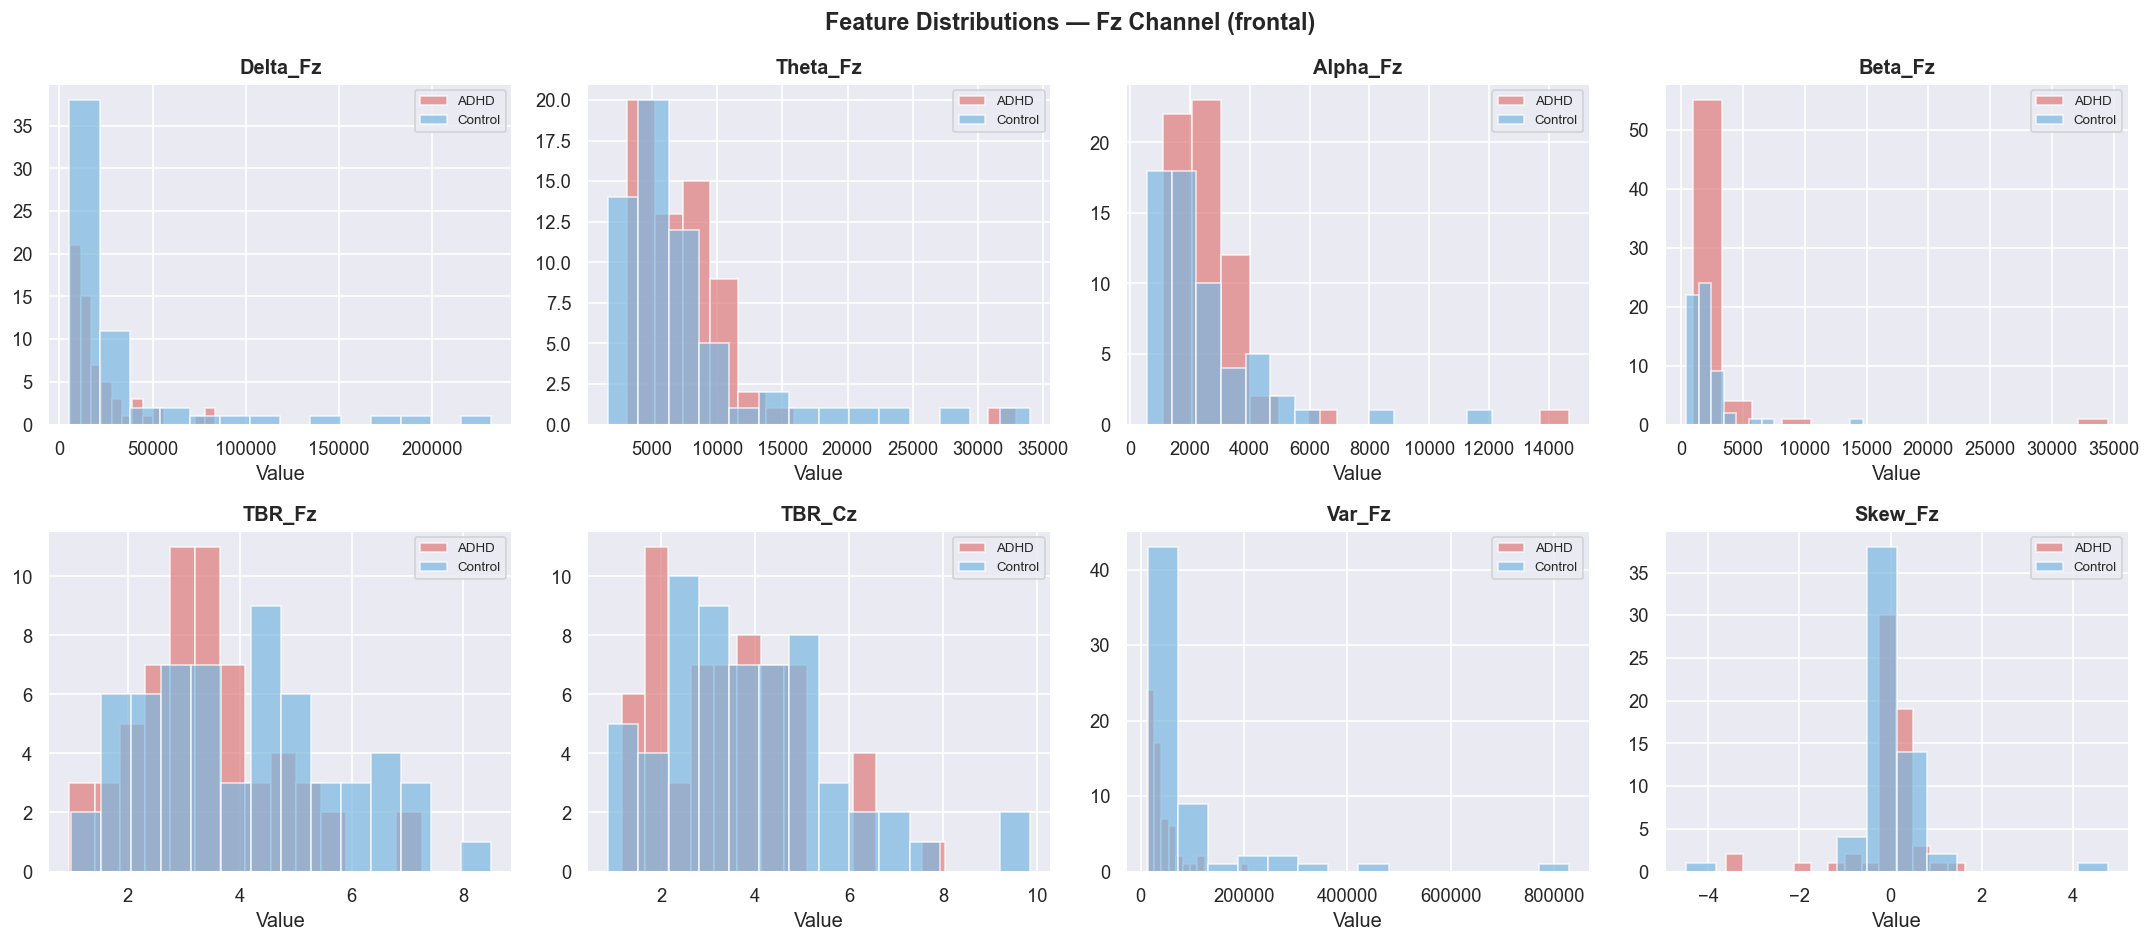

In [5]:
# Show 8 representative features — one per band from Fz (central frontal, clinically relevant)
# plus TBR and a stat feature
highlight_features = [
    'Delta_Fz', 'Theta_Fz', 'Alpha_Fz', 'Beta_Fz',
    'TBR_Fz', 'TBR_Cz', 'Var_Fz', 'Skew_Fz'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colors = {'ADHD': '#e07b7b', 'Control': '#7bb8e0'}

for ax, feat in zip(axes.flat, highlight_features):
    for label, grp in df_features.groupby('label'):
        ax.hist(grp[feat], bins=14, alpha=0.7,
                color=colors[label], label=label, edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions — Fz Channel (frontal)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_feature_distributions.png', bbox_inches='tight')
plt.show()

## 4. Correlation Heatmap — Band Power Features

Check for highly correlated features. This helps understand redundancy before modeling.

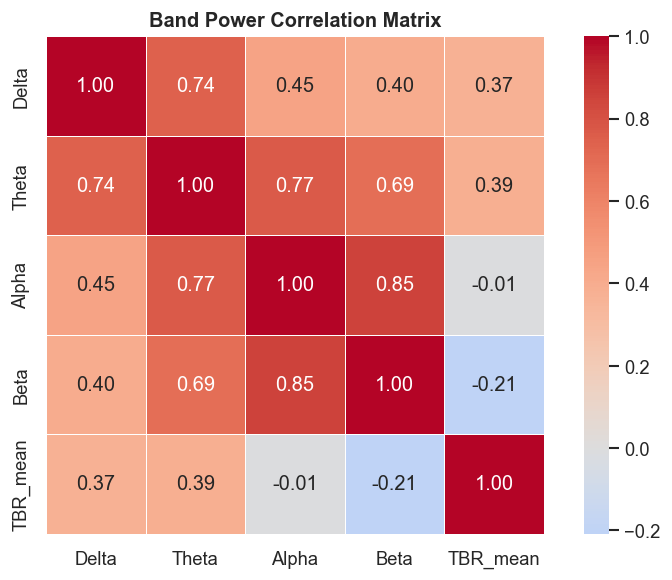

In [6]:
# Use mean band power per band (averaged across channels) for a clean 4×4 view
band_means = pd.DataFrame()
for band in BANDS:
    band_cols = [f'{band}_{ch}' for ch in CHANNELS]
    band_means[band] = df_features[band_cols].mean(axis=1)
band_means['TBR_mean'] = df_features[[f'TBR_{ch}' for ch in CHANNELS]].mean(axis=1)
band_means['label'] = df_features['label']

fig, ax = plt.subplots(figsize=(7, 5))
corr = band_means[['Delta','Theta','Alpha','Beta','TBR_mean']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Band Power Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 5. Feature Summary

In [7]:
print('='*50)
print('FEATURE EXTRACTION SUMMARY')
print('='*50)
print(f'Subjects           : {len(df_features)}')
print(f'Total features     : {len(feature_cols)}')
print(f'  Band power       : {len(BANDS) * len(CHANNELS)}  (4 bands × 19 channels)')
print(f'  Theta/Beta ratio : {len(CHANNELS)}  (1 ratio × 19 channels)')
print(f'  Statistical      : {4 * len(CHANNELS)}  (mean/var/skew/kurt × 19 channels)')
print(f'Feature matrix     : {X.shape}')
print(f'NaN values         : {np.isnan(X).sum()}')
print(f'\nSaved to           : features.csv')
print(f'\nNext: 03_classification.ipynb')

FEATURE EXTRACTION SUMMARY
Subjects           : 121
Total features     : 171
  Band power       : 76  (4 bands × 19 channels)
  Theta/Beta ratio : 19  (1 ratio × 19 channels)
  Statistical      : 76  (mean/var/skew/kurt × 19 channels)
Feature matrix     : (121, 171)
NaN values         : 0

Saved to           : features.csv

Next: 03_classification.ipynb
